# Sheth L.U.J & Sir M.V. College
Practical no. 8    
Ghanshyam Kanojiya

**Aim:** K-Means Clustering    
Apply the K-Means algorithm to group similar data points into clusters.    
Determine the optimal number of clusters using elbow method or silhouette analysis.    
Visualize the clustering results and analyze the cluster characteristics.    

`Using Indian Food Dataset`


## Introduction

In this notebook, we apply **K-Means Clustering** on the **Indian Food Dataset**.

The goal is to group Indian dishes into clusters based on their **preparation and cooking characteristics**.



## Import Required Libraries

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

sns.set_theme()


## Load Dataset

In [46]:
df = pd.read_csv('indian_food.csv')
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (255, 9)


,name,ingredients,diet,prep_time,cook_time,flavor_profile,course,state,region
0,Balu shahi,"Maida flour, yogurt, oil, sugar",vegetarian,45,25,sweet,dessert,West Bengal,East
1,Boondi,"Gram flour, ghee, sugar",vegetarian,80,30,sweet,dessert,Rajasthan,West
2,Gajar ka halwa,"Carrots, milk, sugar, ghee, cashews, raisins",vegetarian,15,60,sweet,dessert,Punjab,North
3,Ghevar,"Flour, ghee, kewra, milk, clarified butter, su...",vegetarian,15,30,sweet,dessert,Rajasthan,West
4,Gulab jamun,"Milk powder, plain flour, baking powder, ghee,...",vegetarian,15,40,sweet,dessert,West Bengal,East


## Dataset Overview

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255 entries, 0 to 254
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   name            255 non-null    object
 1   ingredients     255 non-null    object
 2   diet            255 non-null    object
 3   prep_time       255 non-null    int64 
 4   cook_time       255 non-null    int64 
 5   flavor_profile  255 non-null    object
 6   course          255 non-null    object
 7   state           255 non-null    object
 8   region          254 non-null    object
dtypes: int64(2), object(7)
memory usage: 18.1+ KB


In [48]:
df.isna().sum()

name              0
ingredients       0
diet              0
prep_time         0
cook_time         0
flavor_profile    0
course            0
state             0
region            1
dtype: int64

## Feature Selection for Clustering

K-Means works on **numerical data**.

From the Indian Food dataset, we select:
- `prep_time`
- `cook_time`

These features represent how much effort and time each dish requires.


In [49]:
data = df[['prep_time', 'cook_time']].dropna()
print("Records used for clustering:", data.shape[0])
data.head()

Records used for clustering: 255


,prep_time,cook_time
0,45,25
1,80,30
2,15,60
3,15,30
4,15,40


## Feature Scaling

K-Means is distance-based, so scaling is important.
We standardize the features so that prep_time and cook_time contribute equally.


In [50]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)
scaled_data[:5]

array([[ 0.19187588, -0.197825  ],
       [ 0.67522115, -0.09402793],
       [-0.22242006,  0.52875447],
       [-0.22242006, -0.09402793],
       [-0.22242006,  0.1135662 ]])

## Elbow Method to Find Optimal Number of Clusters

The elbow method helps us choose the best value of **K** by plotting:
- Number of clusters (K)
- Within-cluster sum of squares (WCSS)


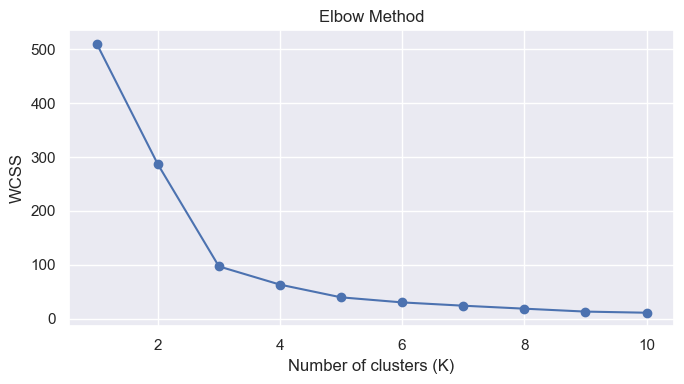

In [51]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(7,4))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters (K)')
plt.ylabel('WCSS')
plt.tight_layout()
plt.show()

## Apply K-Means Clustering

Based on the elbow method, we choose an appropriate number of clusters.
For demonstration, we choose **K = 3**.


In [52]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(scaled_data)

data['Cluster'] = clusters
data.head()

,prep_time,cook_time,Cluster
0,45,25,1
1,80,30,1
2,15,60,1
3,15,30,1
4,15,40,1


## Visualizing Clusters

We visualize clusters using a scatter plot of prep_time vs cook_time.


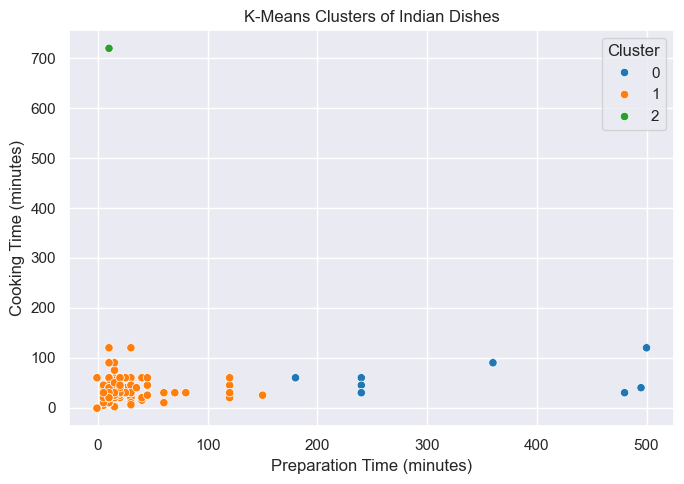

In [53]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    x=data['prep_time'],
    y=data['cook_time'],
    hue=data['Cluster'],
    palette='tab10'
)
plt.title('K-Means Clusters of Indian Dishes')
plt.xlabel('Preparation Time (minutes)')
plt.ylabel('Cooking Time (minutes)')
plt.tight_layout()
plt.show()

## Cluster Centers

In [54]:
centers = scaler.inverse_transform(kmeans.cluster_centers_)
centers_df = pd.DataFrame(centers, columns=['prep_time', 'cook_time'])
centers_df

,prep_time,cook_time
0,322.916667,62.083333
1,16.723140,30.330579
2,10.000000,720.000000


## Interpretation of Clusters

Each cluster represents a group of dishes with similar cooking behavior:

- **Cluster 0**: Dishes with relatively low preparation and cooking time  
- **Cluster 1**: Dishes with moderate preparation and cooking time  
- **Cluster 2**: Dishes that require long preparation and/or cooking time  

This clustering helps us understand:
- Quick dishes vs time-consuming dishes  
- Which dishes are suitable for daily cooking vs special occasions  

K-Means clustering allows us to discover these patterns **without using any labels**.


## Conclusion

In this practical, we successfully applied **K-Means Clustering** on the Indian Food Dataset.

We:
- Selected appropriate numerical features  
- Scaled the data  
- Used the elbow method to find optimal K  
- Built and visualized a K-Means clustering model  
- Interpreted the resulting clusters  

This demonstrates how unsupervised learning can be used to discover hidden patterns in real-world datasets.


# Example 2:
### K-Means Image Color Quantization (Custom Image)

**Dataset:**  
Custom image file (e.g., Jaipur.jpg)



## Import Required Libraries

In [55]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.cluster import MiniBatchKMeans

## Load Custom Image

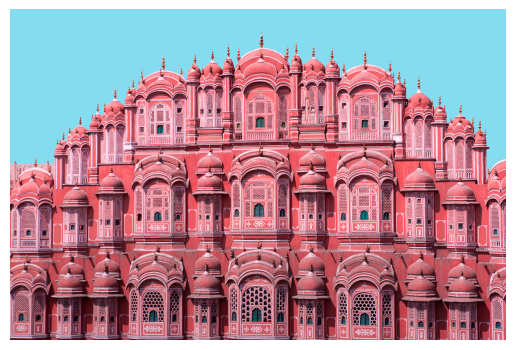

In [56]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("Jaipur.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis('off')
plt.show()
jaipur = np.array(img)

In [57]:
jaipur.shape

(800, 1200, 3)

## Prepare Pixel Data

In [58]:
data = jaipur.reshape(-1, 3)
data = data / 255.0
data.shape

(960000, 3)

## Visualize Color Space

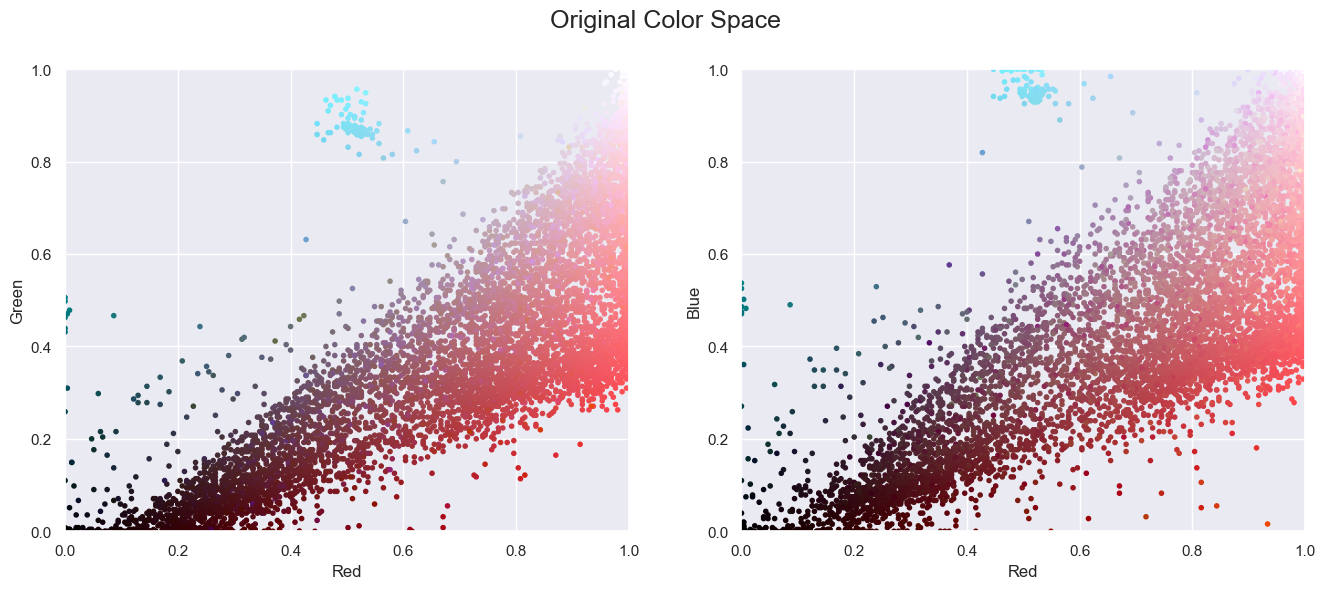

In [59]:
def plot_pixels(data, title, colors=None, N=10000):
    if colors is None:
        colors = data

    rng = np.random.default_rng(0)
    i = rng.permutation(data.shape[0])[:N]
    colors = colors[i]
    R, G, B = data[i].T

    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    ax[0].scatter(R, G, color=colors, marker='.')
    ax[0].set(xlabel='Red', ylabel='Green', xlim=(0, 1), ylim=(0, 1))

    ax[1].scatter(R, B, color=colors, marker='.')
    ax[1].set(xlabel='Red', ylabel='Blue', xlim=(0, 1), ylim=(0, 1))

    fig.suptitle(title, size=18)

plot_pixels(data, title='Original Color Space')

## Apply K-Means Clustering

In [60]:
kmeans = MiniBatchKMeans(n_clusters=16, random_state=0)
kmeans.fit(data)

new_colors = kmeans.cluster_centers_[kmeans.predict(data)]

## Reduced Color Space


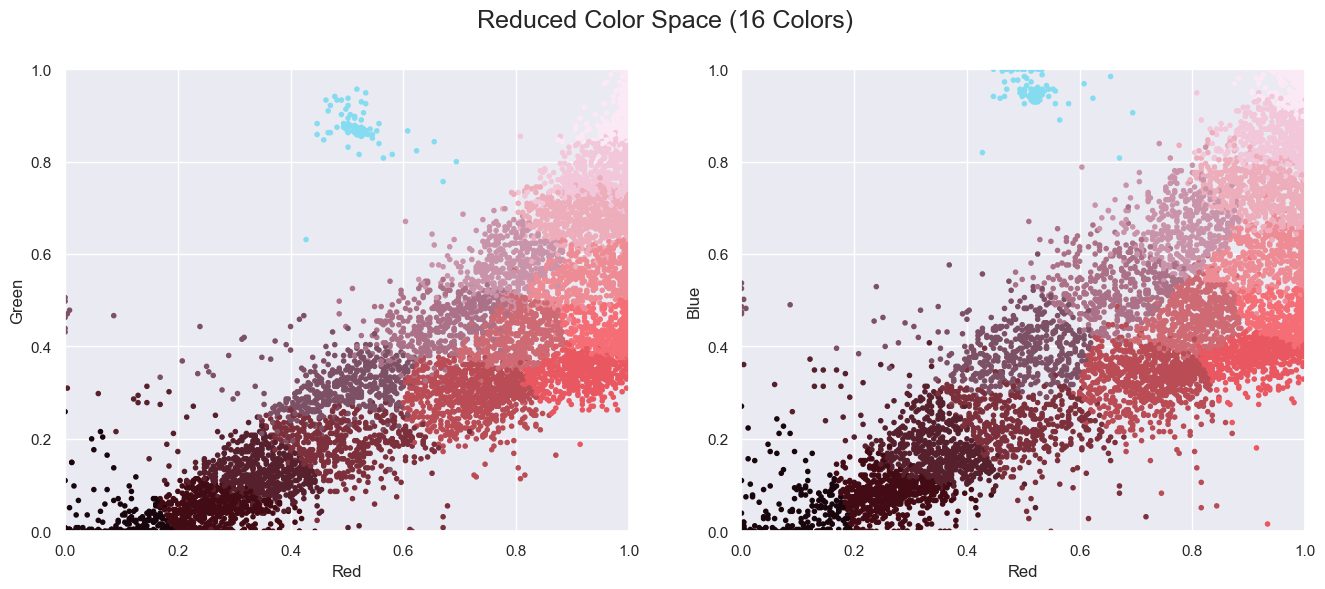

In [61]:
plot_pixels(
    data,
    colors=new_colors,
    title='Reduced Color Space (16 Colors)'
)

## Reconstruct Image

In [62]:
jaipur_recolored = new_colors.reshape(jaipur.shape)


## Original vs Recolored Image

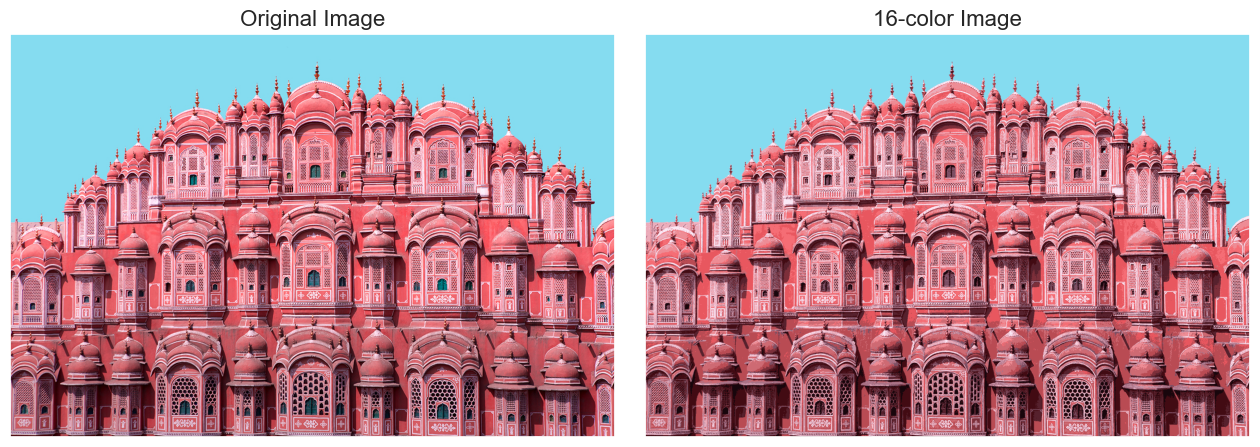

In [63]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6),
                       subplot_kw=dict(xticks=[], yticks=[]))
fig.subplots_adjust(wspace=0.05)

ax[0].imshow(jaipur)
ax[0].set_title('Original Image', size=16)

ax[1].imshow(jaipur_recolored)
ax[1].set_title('16-color Image', size=16)

plt.show()


## Conclusion

K-Means clustering groups similar pixel colors and replaces them with cluster centroids.
This reduces the image to a fixed number of representative colors while preserving
the overall visual structure.
